# W04A · 이웃을 고려한 CF와 사용자의 평가 경향
**딥러닝응용I(추천시스템) · 동덕여자대학교 데이터사이언스전공 · 유원상 교수 · 2026-2**

2026-09-22 · 주교재3.4–3.6. 목표 영화 평가자 중 이웃을 고르고, 검증으로 k를 선택하고, 사용자 평균을 보정한다.
[강의자료](https://github.com/lunalab-ai/recommender/blob/2026-fall-w04a-v2/course/notion/sessions/w04a-neighborhood-cf.md)

CPU에서 첫 셀부터 실행한다. `None` 빈칸은 미완성이어도 독립 시연을 막지 않는다. E1–E6은 예상·구현·비교 활동이다.


### 5.2 `fit`은 무엇을 저장하는가?

`NeighborCF`는 지난 차시의 `UserCF`를 확장한 클래스다. 생성자는 설정을 보관한다. `fit(train)`은 관측 표를 행렬로 바꾸고, 관측 마스크·사용자 유사도·사용자와 영화 평균·이미 평가한 영화 집합을 계산하여 객체에 저장한다. 이 통계를 이용해 여러 쌍의 평점을 반복 예측할 수 있다.

여기서 `fit`은 경사하강법으로 신경망 가중치를 학습하는 함수가 아니다. 평점과 관측 구조에서 필요한 통계를 구성하는 단계다. k의 최적화도 `fit`이 자동으로 수행하지 않는다. 설정을 비교하는 `validation_sweep`와 검증표의 선택 과정이 별도로 필요하다.

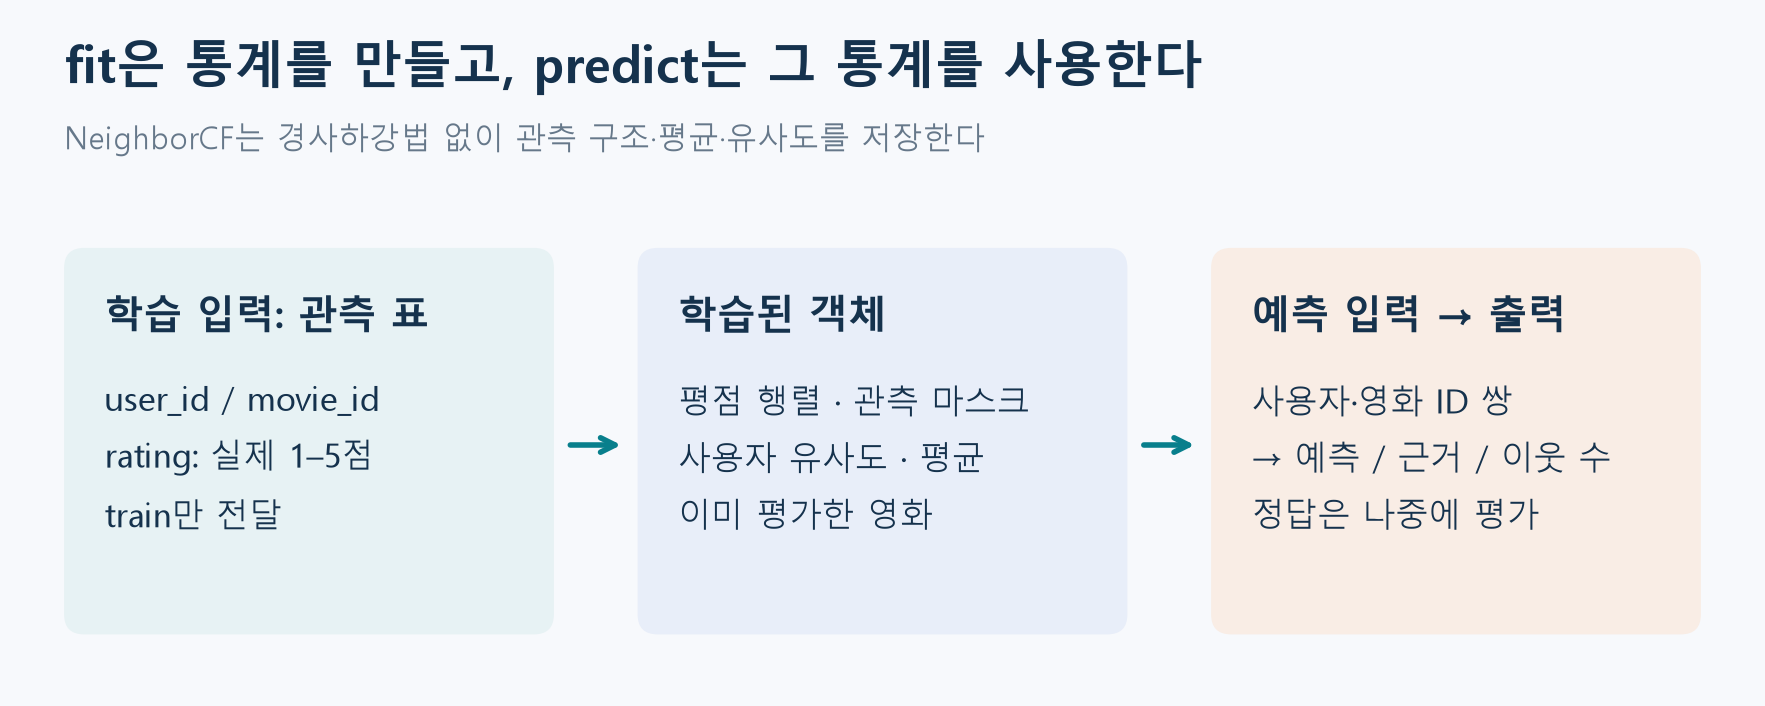

그림 8. 학습 때는 정답 평점이 필요하지만 예측 때는 사용자·영화 ID만 전달한다. 실제 정답은 예측이 끝난 뒤 평가 함수에 전달한다. 화살표의 방향을 뒤집어 test 평점을 학습 상태에 넣지 않는다.

| 객체의 상태 | 저장하는 내용 | 학습 후 모양 |
| --- | --- | --- |
| `rating_matrix_` | 원평점과 미관측 NaN | 사용자 수 × 영화 수 DataFrame |
| `similarity_` | 사용자 간 원평점 코사인 | 사용자 수 × 사용자 수 DataFrame |
| `user_means_` | 관측 사용자 평균 | 사용자 ID 인덱스 Series |
| `seen_` | 사용자가 이미 평가한 영화 | 사용자별 영화 ID 집합 |

생성자 직후에는 이 상태가 없으므로 예측할 수 없다. `fit`은 자기 자신을 반환하므로 `NeighborCF(...).fit(train)`처럼 연결할 수 있다. 원래 입력 표를 직접 수정하지 않으며, 이 클래스 자체는 파일 다운로드를 수행하지 않는다. 데이터 준비 함수의 역할과 구별한다.


[Figure source](https://raw.githubusercontent.com/lunalab-ai/recommender/2026-fall-w04a-v2/course/notion/assets/w04a/model-state.png)


## 1. 실행 환경과 작은 평점표
고정 수업 태그의 패키지를 현재 커널에 설치한다. 설치 오류는 숨기지 않는다. 런타임 재시작 안내가 나오면 재시작 후 첫 셀부터 실행한다.
`toy_ratings()`는 5명·5편의 독자 합성 관측18행을 만든다. `NeighborCF(k,centered,threshold)`는 설정을 저장하고 `fit(train)`이 관측 행렬·코사인·평균을 만든다. k=0은 전체 이웃이다.
[모델/API 정의](https://github.com/lunalab-ai/recommender/blob/2026-fall-w04a-v2/src/luna_recsys/neighborhood.py#L11)


In [ ]:
import os, sys, subprocess
os.environ['GRADIO_ANALYTICS_ENABLED']='False'
IN_COLAB='google.colab' in sys.modules
COURSE_VERSION='2026-fall-w04a-v2'
if IN_COLAB:
    subprocess.run([sys.executable,'-m','pip','install','-q',
        f'luna-recommender-course[apps] @ git+https://github.com/lunalab-ai/recommender.git@{COURSE_VERSION}',
        'gradio==6.27.0'],check=True)
import numpy as np
import pandas as pd
import gradio as gr
from IPython.display import display
from sklearn.metrics import root_mean_squared_error
from luna_recsys.collaborative import UserCF, toy_ratings
from luna_recsys.neighborhood import NeighborCF, validation_sweep
from luna_recsys.neighborhood_app import neighbor_view, build_neighbor_app
from luna_recsys.cf_app import build_cf_app
from luna_recsys.ranking import FourMethodRecommender
from luna_recsys.datasets import prepare_movielens
from luna_recsys.evaluation import split_ratings
toy=toy_ratings()
small=NeighborCF(k=2).fit(toy)
R=small.rating_matrix_
display(R)
print('Python',sys.version.split()[0],'NumPy',np.__version__,'pandas',pd.__version__,'Gradio',gr.__version__)


### 1.3 수식의 기호를 표의 행과 열에 연결하기

| 기호 | 읽는 방법 | U1의 D 평점 예측에서 |
| --- | --- | --- |
| $u$ | 추천받을 대상 사용자 | U1 |
| $v$ | 의견을 제공하는 이웃 사용자 | U2, U3, U4 등 |
| $i$ | 평점을 예측할 목표 영화 | D |
| $r_{vi}$ | 이웃이 목표 영화에 실제로 준 평점 | U2의 D는 5 |
| $s_{uv}$ | 대상과 이웃의 유사도 | U1–U2는 약 0.645423 |
| $I_v$ | 사용자가 학습 자료에서 평가한 영화 집합 | U4는 A, B, D |
| $N_{u,i}$ | 목표 영화에 사용할 유효 이웃 집합 | k=2이면 U4, U2 |

평점 표의 빈칸은 **0점 평가가 아니라 관측하지 못한 값**이다. U1의 평균은 $(5+3+1)/3=3$이며, 다섯 영화 중 두 개를 평가하지 않았다고 분모를 5로 늘리지 않는다. 코사인 계산을 위한 벡터에서는 빈칸을 0으로 표현하지만, 그 계산용 표현을 평점 통계와 섞지 않는다.

U1과 U4의 코사인을 한 번 다시 계산해 보자. 영화 순서를 A–E로 고정하면 U1은 $(5,3,1,0,0)$, U4는 $(5,3,0,4,0)$이다.

$$
\boldsymbol{x}_1^{\mathsf T}\boldsymbol{x}_4=5\times5+3\times3+1\times0+0\times4+0\times0=34
$$

$$
s_{14}=\frac{34}{\sqrt{35}\sqrt{50}}\approx0.812756
$$

공통 평가 영화 A·B만으로 벡터를 다시 만드는 계산과 구분한다. 여기서는 전체 영화 축을 유지하므로 U4의 D 평점도 U4 벡터의 길이에 들어간다. 이는 지난 차시와 동일한 설계다. 오늘 평균 보정을 추가해도 이 유사도 정의는 유지한다.

> **확인 Q1.** U4는 U1과 가장 비슷하다. 그렇다면 U1의 미평가 영화 D와 E를 예측할 때 U4를 항상 사용할 수 있을까? 표의 빈칸을 근거로 설명하라.


### E1 · 목표 평가자부터 고르기
U1의 영화 E(ID5)를 k=1로 예측한다. 아래 함수는 `R`, 유사도Series, 대상ID, 영화ID, k를 받아 선택한 이웃ID 목록을 반환해야 한다. 목표 영화 평가자와 양의 유사도를 먼저 고르고, 자신을 제외한 뒤 정렬하라. 전체 사용자 상위 k명을 먼저 고르면 어떤 문제가 생기는지도 적어라.
pandas의 `notna()`는 관측 여부, `sort_values()`는 값 정렬, `head(k)`는 앞 k행 선택이다.


In [ ]:
def choose_neighbors(rating_matrix, similarities, user_id, movie_id, k):
    return None  # 선택된 사용자 ID 목록을 반환하도록 완성
chosen=choose_neighbors(R,small.similarity_.loc[1],1,5,1)
if chosen is None:
    print('E1: 목표 영화 평가자 안에서 이웃을 선택하세요.')
else:
    assert list(chosen)==small.explain(1,5).head(1).user_id.tolist()


## 2. 선택된 이웃과 가중평균
`explain(u,i)`는 선택된 전체 이웃의 유사도·평점·사용자 평균·편차·정규화 가중치·기여도를 반환한다. 원평점 방식의 기여도합은 clip 전 예측과 같다. `predict_details` 입력의 rating 열은 예측에 사용하지 않는다.


In [ ]:
pair=pd.DataFrame({'user_id':[1],'movie_id':[4]})
display(small.explain(1,4))
display(small.predict_details(pair))


### 2.4 D의 평점을 직접 계산하기

U1–D의 $k=2$ 이웃은 U4와 U2다. 반올림하기 전 유사도로 계산한 결과는 약 4.442623점이다.

$$
\widehat r_{1D}=\frac{0.812756\times4+0.645423\times5}{0.812756+0.645423}\approx4.442623
$$

| 이웃 수 | D에 사용한 이웃 | 원평점 예측 |
| --- | --- | --- |
| 1 | U4 | 4.000000 |
| 2 | U4, U2 | 4.442623 |
| 전체 | U4, U2, U3 | 3.685360 |

한 번의 분수 계산으로 끝내지 않고 가중치와 기여도를 나눠 보자. 전체 유사도 합은 약 1.458179이며, 이 값으로 각 유사도를 나누면 가중치 합이 1이 된다.

$$
w_{uv}=\frac{s_{uv}}{\sum_{z\in N_{u,i}}s_{uz}},\qquad \sum_{v\in N_{u,i}}w_{uv}=1
$$

| 계산 단계 | U4 | U2 | 합 또는 결과 |
| --- | --- | --- | --- |
| 유사도 | 0.812756 | 0.645423 | 1.458179 |
| 정규화 가중치 | 0.557377 | 0.442623 | 1.000000 |
| D 평점 | 4 | 5 | 단순평균은 4.5 |
| 가중치 × 평점 | 2.229508 | 2.213115 | **4.442623** |

U4의 가중치가 더 크므로 결과는 단순평균 4.5보다 U4의 4점 쪽에 가깝다. 양의 가중치 합이 1인 평균이므로 두 평점 4와 5 사이에 있어야 한다. 값이 6이나 0이면 분모, ID 정렬, 중복 또는 미관측 처리를 점검한다. k를 3으로 늘리면 U3의 D=1이 들어와 예측이 내려간다. 이것은 이 표의 결과이지 k가 커지면 항상 점수가 내려간다는 법칙이 아니다.

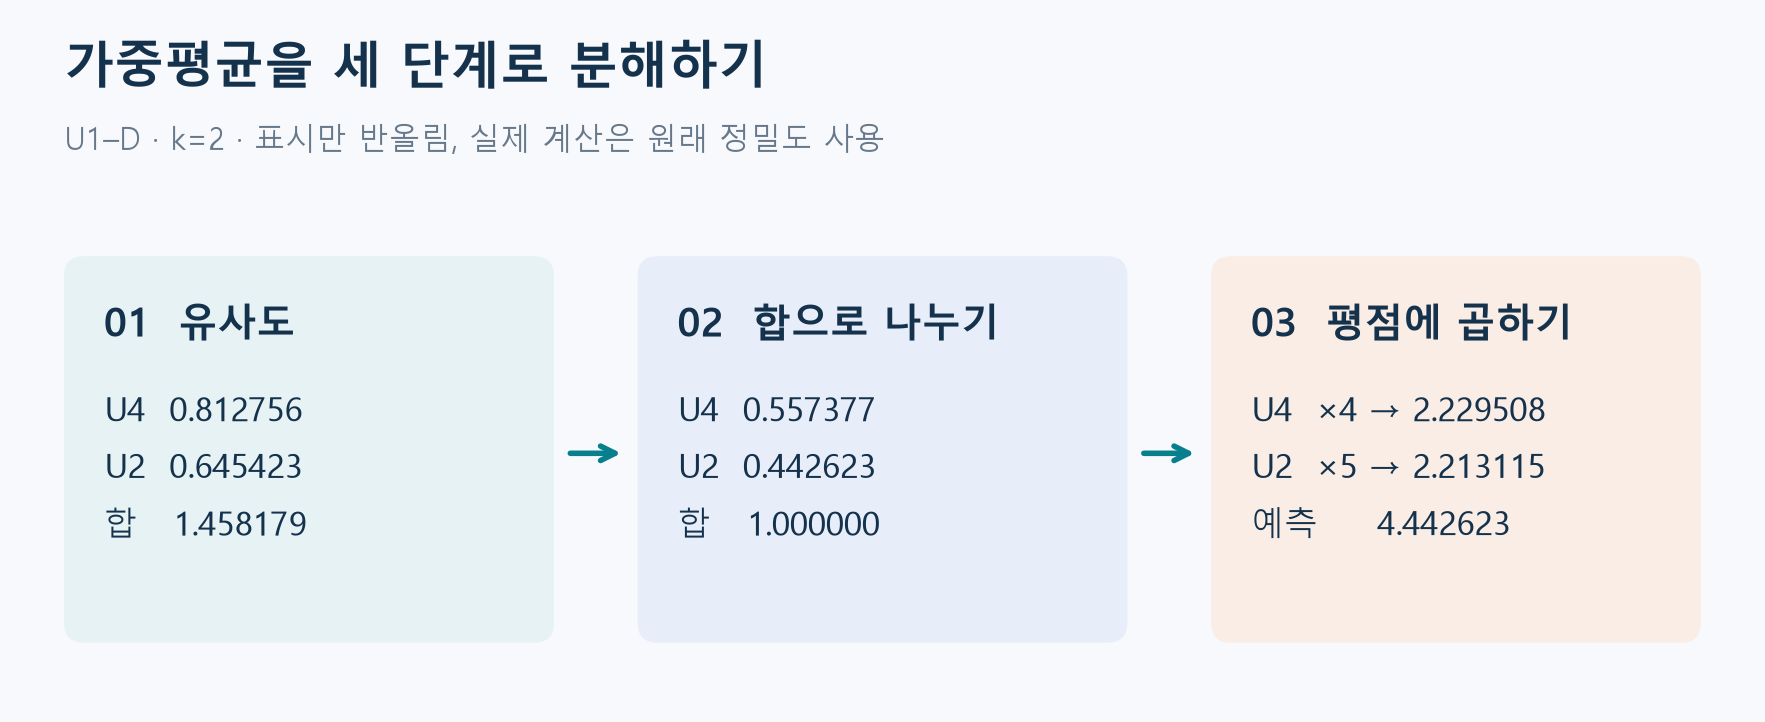

그림 4. 정규화 전 유사도와 정규화 후 가중치를 구분한다. 최종 예측은 오른쪽 두 기여도의 합이다. 분자만 상위 두 명으로 계산하고 분모에는 세 명의 유사도를 넣으면 다른 식이 된다.

> **확인 Q2.** U4와 U2의 평점에 같은 1점을 더하고 이웃과 가중치를 고정하면 예측값은 얼마나 변할까? 가중치의 합을 이용해 설명하라.

### 2.5 코드에서 사용자 대응을 유지하기

행 인덱스가 사용자 ID인 Series끼리는 ID로 정렬해 결합해야 한다. 유사도를 따로 내림차순 정렬한 배열과 원래 순서의 평점 배열을 곱하면 서로 다른 사람의 값을 곱할 수 있다. `pd.concat(..., axis=1)`은 같은 인덱스를 가진 값을 같은 행에 놓는다. 결합한 표 전체를 정렬한 다음 배열로 바꾸는 순서가 안전하다.

수업 모듈은 이 선택을 여러 영화에 대해 효율적으로 수행한다. 내부에서는 유사도 순서가 먼저 저장돼 있어도 영화별 관측 여부를 적용한 뒤 유효한 행을 누적하여 k개까지 남긴다. 즉, 코드에서 정렬이 앞에 보인다는 사실만으로 “잘못된 top-k 후 필터”라고 판단하면 안 된다. **인원 제한이 관측 마스크 적용 전인지 후인지**가 핵심이다.

**$k$와 추천 수 $N$은 다르다.** $k$는 각 영화의 예측에 사용할 사람 수를 제한한다. 추천 수 $N$은 예측을 마친 뒤 화면에 표시할 미평가 영화의 수를 제한한다.


[Figure source](https://raw.githubusercontent.com/lunalab-ai/recommender/2026-fall-w04a-v2/course/notion/assets/w04a/weighted-sum.png)


### E2 · 유사도와 평점의 대응 오류
버그: `s.sort_values(ascending=False).to_numpy() @ ratings.to_numpy()`처럼 유사도만 정렬하면 사용자 대응이 깨진다. D의 후보를 사용자ID로 결합한 DataFrame에서 함께 정렬하여 k=2 원평점 예측을 계산하라. `pd.concat(...,axis=1)`은 인덱스로 열을 정렬해 결합한다.


In [ ]:
aligned_prediction=None
if aligned_prediction is None:
    print('E2: 사용자ID를 유지한 표 전체를 정렬하세요.')
else:
    assert np.isclose(aligned_prediction,small.predict(pair)[0])


## 3. MovieLens 준비와 관측 분할
공식 MovieLens100K를 자동 다운로드하고 크기·ID를 검사한다. 다음 실행은 캐시를 사용한다. 기본 `real` 실패는 오류로 알린다. 네트워크가 불가능한 경우에만 `DATA_MODE='synthetic'`을 직접 선택한다. 합성 결과는 강의의 실제 측정값과 다르다.
`split_ratings`는 가능하면 사용자별로 층화한다. 바깥20%를 test로 남기고 남은80%의25%를 validation으로 분리하면60/20/20이다. 같은 사용자와 영화가 여러 분할에 있어도 같은 관측 쌍은 겹치면 안 된다.
[데이터 준비 API](https://github.com/lunalab-ai/recommender/blob/2026-fall-w04a-v2/src/luna_recsys/datasets.py#L62) · [분할 API](https://github.com/lunalab-ai/recommender/blob/2026-fall-w04a-v2/src/luna_recsys/evaluation.py#L28)


In [ ]:
DATA_MODE='real'
prepared=prepare_movielens('data/local/w04a',mode=DATA_MODE)
data=prepared.data
print(prepared.description)
print('사용자/영화/평점:',len(data.users),len(data.movies),len(data.ratings))
outer=split_ratings(data.ratings,test_size=.2,seed=20260922)
inner=split_ratings(outer.train,test_size=.25,seed=20260923)
train,validation,test=inner.train,inner.test,outer.test
print('train/validation/test:',len(train),len(validation),len(test))
def pair_set(frame):
    return set(frame[['user_id','movie_id']].itertuples(index=False,name=None))
assert not pair_set(train)&pair_set(validation)
assert not pair_set(train)&pair_set(test)
assert not pair_set(validation)&pair_set(test)


### 3.4 RMSE를 작은 표에서 직접 계산하기

RMSE는 예측값과 실제 평점의 차이를 제곱하여 평균한 뒤 제곱근을 취한다. 오차의 부호를 없애고 큰 오차를 더 강하게 반영한다. 다음은 계산법을 익히기 위한 독립 예제이며 MovieLens 측정값이 아니다.

| 관측 | 실제 평점 | 예측 평점 | 오차: 실제−예측 | 제곱오차 |
| --- | --- | --- | --- | --- |
| 첫 번째 | 5 | 4 | 1 | 1 |
| 두 번째 | 2 | 3 | −1 | 1 |
| 세 번째 | 4 | 4 | 0 | 0 |

$$
\operatorname{RMSE}=\sqrt{\frac{1+1+0}{3}}=\sqrt{\frac23}\approx0.816497
$$

분모는 사용자 수나 영화 수가 아니라 **평가에 사용한 관측 평점의 수**다. 오차를 단순히 더하면 1과 −1이 상쇄되지만, RMSE에서는 둘 다 제곱오차 1로 남는다. 반환값의 단위는 원래 평점과 같다. 다만 RMSE가 0.8이라는 결과를 “모든 영화에서 정확히 0.8점 틀린다”라고 읽지는 않는다.

이번 표는 관측별 평균이므로 평가 관측이 많은 사용자가 전체 점수에 더 큰 비중을 갖는다. 사용자별 RMSE를 먼저 계산한 뒤 사용자 간 평균을 구하면 다른 평가 기준이 된다. 서로 다른 기준의 값을 같은 열에서 비교하지 않는다.

### 3.5 학습·검증·테스트를 나누는 이유

`fit`에 전달하는 train은 유사도와 평균을 만드는 자료다. validation은 k와 평균 보정 여부를 선택하는 자료다. test는 설정 선택을 끝낸 뒤 성능을 보고하는 자료다. validation이나 test의 평점을 평균 계산에 미리 넣으면 정답 일부를 예측기의 재료로 쓴 셈이다. 이것이 데이터 누수다.

같은 validation에 여러 후보를 적용해야 k의 차이를 비교할 수 있다. 후보마다 데이터를 새로 무작위 분할하면 성능 차이가 설정 때문인지 분할 때문인지 구별하기 어렵다. 난수 seed를 고정하면 이번 분할을 재현할 수 있지만, 그 seed 하나에서의 결과가 모든 분할을 대표한다는 보장은 없다.

바깥 분할에서 100,000행 중 20%를 test로 남기면 80,000행이 남는다. 그 80,000행의 25%인 20,000행을 validation으로 떼면 train은 60,000행이다. 20%와 25%가 서로 다른 모집단에 적용된다는 점을 주의한다. 최종 설정을 고정한 뒤에는 train과 validation을 합친 80,000행으로 평균과 유사도를 다시 계산한다. test 20,000행은 이 재학습에도 포함하지 않는다.


### 같은 검증 관측에서 이웃 수 비교
`validation_sweep(train,validation,k_values)`는 train에서만 통계를 계산하고16개 후보의 검증 RMSE와 coverage, 평균 실제 이웃 수를 반환한다. 이 함수에는 test 인자가 없다. k=0은 모든 양의 유사도 평가자다. 표는 RMSE 오름차순이며 동점은 k와 보정 여부 순이다.


In [ ]:
scores=validation_sweep(train,validation,[1,5,10,20,30,40,60,0])
display(scores.round(6))
display(scores.pivot(index='k',columns='centered',values='rmse').rename(columns={False:'원평점',True:'평균 보정'}))


### E3 · 선택용 데이터와 마지막 평가
표에서 선택할 k와 보정 여부를 적어라. test RMSE로16개 후보를 정렬하는 코드는 왜 잘못된 선택 절차인지 설명하라. 검증 선택 후 train+validation으로 다시 학습해도 되는 이유와 그때 test를 합치면 안 되는 이유도 적어라.


In [ ]:
selected_k=None
selected_centered=None
if selected_k is None or selected_centered is None:
    print('E3: validation 표에서 설정을 선택하세요.')
else:
    assert int(selected_k)==int(scores.iloc[0].k)
    assert bool(selected_centered)==bool(scores.iloc[0].centered)


### 고정한 설정으로 test 한 번 평가
다음은 빈칸과 독립된 시연이다. 검증표의 최저 설정을 고정하고80% 관측으로 재학습한다. 최종 test 정답은 예측을 만든 뒤 RMSE 계산에만 전달한다. 작은 RMSE는 순위 만족도 보장이 아니다.


In [ ]:
best=scores.iloc[0]
final_model=NeighborCF(k=int(best.k),centered=bool(best.centered)).fit(outer.train)
final_details=final_model.predict_details(test[['user_id','movie_id']])
final_rmse=root_mean_squared_error(test.rating,final_details.prediction)
print('고정한 설정:',int(best.k),bool(best.centered))
print('test RMSE:',final_rmse,'CF coverage:',final_details.basis.eq('cf').mean())
print('clip 적용:',int((final_details.prediction!=final_details.raw_prediction).sum()))


## 4. 사용자의 평가 경향 보정
$$\widehat r_{ui}=\overline r_u+\frac{\sum_{v\in N_{u,i}}s_{uv}(r_{vi}-\overline r_v)}{\sum_{v\in N_{u,i}}s_{uv}}.$$
이웃 평균을 빼 상대적 선호를 모으고 대상 사용자 평균을 더한다. 원평점 코사인은 그대로 유지한다. 평균은 train 관측만 사용한다. `raw_prediction`은 clip 전, `prediction`은1~5점 범위의 최종값이다.


In [ ]:
centered_small=NeighborCF(k=2,centered=True).fit(toy)
display(centered_small.user_means_.rename('관측 사용자 평균'))
display(centered_small.explain(1,4))
display(centered_small.predict_details(pair))


### 4.4 왜 마지막에 내 평균을 더하는가?

편차 0.973770은 평점 자체가 아니다. 선택된 이웃들이 D를 각자의 평균보다 얼마나 높게 평가했는지를 요약한 값이다. 이것을 U1의 평점 척도로 돌려놓기 위해 U1의 평균 3을 더한다. U4나 U2의 평균을 마지막에 한 번 더 더하면 대상 사용자가 아닌 이웃의 기준으로 돌아간다.

평균 보정식은 원평점 예측과 다음처럼 연결된다. 여기서는 **같은 이웃·같은 가중치·clip 전**이라는 조건이 중요하다.

$$
\widehat r_{ui}^{\mathrm{centered}}=\widehat r_{ui}^{\mathrm{raw}}+\overline r_u-\sum_{v\in N_{u,i}}w_{uv}\overline r_v
$$

즉, 원평점 예측에서 이웃들의 가중평균 점수 수준을 빼고 대상 사용자의 평균을 더한다. U1–D의 이웃 평균 가중합은 약 3.468852이므로, 4.442623에서 3.468852를 빼고 3을 더하면 3.973770이다. 대상 평균이 이웃 평균 가중합보다 높다면 보정 후 예측이 오를 수도 있다.

이 등식은 “평균 보정이면 항상 낮아진다”는 오해를 고쳐 준다. 보정의 방향은 대상과 이웃의 기준 수준 차이로 결정된다. clip이 적용되면 최종 화면 값끼리는 이 등식이 그대로 성립하지 않을 수 있으므로 `raw_prediction`을 비교한다.

> **확인 Q5.** 모든 이웃의 목표 영화 평점이 각자 평균과 정확히 같다면 평균 보정 예측은 무엇이 되는가? 두 단계로 설명하라.

### 4.5 평균 보정과 Pearson 유사도를 혼동하지 않기

평균을 빼는 연산이 등장한다고 두 방법이 같은 것은 아니다. Pearson 유사도는 **누가 비슷한지 측정하는 단계**에서 중심화한 패턴을 비교한다. 이번 평점편차 CF는 원평점 코사인으로 선택한 이웃을 유지하고 **그 이웃의 의견을 집계하는 단계**에서 사용자 평균을 제거한다.

| 비교 항목 | 이번 수업의 평점편차 CF | 유사도를 Pearson으로 변경 |
| --- | --- | --- |
| 바꾸는 위치 | 선택된 평점을 집계하는 식 | 사용자 유사도 계산 |
| 이웃 순서 | 같은 k·임계값에서 유지 | 바뀔 수 있음 |
| 중심화 기준 | 각 이웃의 train 관측 평균 | Pearson의 관측 범위·평균 정의에 따름 |
| 별도 검토 | 대상 평균 복원·범위 제한 | 공통 관측 수·분산 0·음수 유사도 |

두 변경을 동시에 적용할 수도 있지만, 그러면 어떤 변경이 성능 차이를 만들었는지 따로 비교해야 한다. 오늘은 집계식의 변화에 집중하기 위해 유사도 정의를 고정한다.


### E4 · 누구의 평균을 빼고 더하는가?
버그① `R.fillna(0).mean(axis=0)`으로 사용자 평균을 계산했다. 버그② 모든 이웃 평점에서 U1 평균을 빼고 마지막에 이웃 평균을 더했다. 두 오류를 설명하고 U1–D(k2) 보정 예측을 직접 계산하라. `axis=1`은 사용자별 행 평균이다.


In [ ]:
corrected_prediction=None
if corrected_prediction is None:
    print('E4: 관측 행 평균 → 각 이웃 평균 제거 → 대상 평균 복원')
else:
    assert np.isclose(corrected_prediction,centered_small.predict(pair)[0])


### 5.4 입력과 반환값을 실제 코드에 연결하기

`train`은 한 행이 하나의 관측인 pandas DataFrame이다. `user_id`, `movie_id`, `rating` 세 열이 필요하고 평점은 1–5 범위다. 같은 사용자–영화 쌍의 중복은 허용하지 않는다. `pairs`에는 예측할 `user_id`, `movie_id`만 있으면 된다. 두 표의 행 수가 같을 필요는 없다.

```python
train_toy = toy_ratings()           # 18개의 관측, 5명·5편
model = NeighborCF(k=2, centered=True)
model.fit(train_toy)               # 행렬·유사도·평균 구성
pairs = pd.DataFrame({"user_id": [1], "movie_id": [4]})
details = model.predict_details(pairs)
evidence = model.explain(user_id=1, movie_id=4)
```

이 호출은 한 행의 예측 상세 표와 두 행의 이웃 근거 표를 만든다. `details`의 인덱스와 행 순서는 `pairs`를 따른다. `evidence`는 선택된 이웃 전체를 유사도 내림차순으로 반환한다. 동점에서는 사용자 ID 순서가 일정하도록 처리한다. 이는 결과를 반복 실행했을 때 순서가 불필요하게 바뀌는 것을 막는다.

| 상세 예측 열 | 의미 | 위 호출의 기대값 |
| --- | --- | --- |
| `prediction` | 1–5로 제한한 최종 평점 | 약 3.973770 |
| `raw_prediction` | 제한하기 전 계산 결과 | 약 3.973770 |
| `basis` | CF 또는 평균 대체 종류 | `cf` |
| `n_contributors` | 실제 선택된 이웃 수 | 2 |
| `weight_sum` | 정규화 전 유사도 합 | 약 1.458179 |

`evidence`의 `similarity`는 정규화 전 유사도, `weight`는 합이 1인 가중치다. `rating`은 목표 영화의 관측 평점, `user_mean`은 해당 이웃의 train 평균, `deviation`은 두 값의 차이다. `contribution`은 원평점 모드에서는 가중치×평점이고 보정 모드에서는 가중치×편차다. 같은 열 이름이라도 설정에 따라 집계 대상이 달라진다는 점을 읽어야 한다.

#### 데이터를 준비하고 분할하는 함수

`prepare_movielens(cache_dir, mode="real")`은 캐시 경로를 받아 준비 결과 객체를 반환한다. `prepared.data`에 사용자·영화·평점 표가 있고 `prepared.description`과 `prepared.mode`로 실제 또는 합성 모드를 확인한다. 최초 호출은 네트워크 다운로드와 로컬 캐시 저장이 발생할 수 있다. 캐시가 있으면 재사용한다. `split_ratings(ratings, test_size=..., seed=...)`는 원본 표를 바꾸지 않고 `train`, `test`를 가진 분할 결과를 반환한다. 내부 validation 분할에서는 반환 필드 이름이 `test`여도 역할은 validation이다.

#### 검증표를 만드는 함수

`validation_sweep(train, validation, k_values)`는 각 k와 보정 여부 두 가지를 비교한다. k 후보 8개면 반환 표는 16행이다. `rmse`, `coverage`, `mean_neighbors`를 포함하고 RMSE가 작은 순서로 정렬한다. `scores.iloc[0]`은 정수 위치 0의 첫 행이므로 최저 설정을 가리킨다. `.loc[0]`의 인덱스 라벨 접근과 개념적으로 구별한다. 이 함수는 train과 validation의 관측 쌍이 겹치면 오류를 낸다.


## 5. 누적 추천 앱의 callback
앱은 설정 효과를 탐색하는 train 모델을 사용한다. 최종 test 점수 선택과 분리한다. `neighbor_view(model,movies,user_id,k,centered,threshold,top_n)`은 요약HTML·추천표·첫 추천의 전체 이웃 표를 반환한다. 원본 모델 설정은 변경하지 않는다. `top_n`은 추천 영화 수다.
[callback/API 정의](https://github.com/lunalab-ai/recommender/blob/2026-fall-w04a-v2/src/luna_recsys/neighborhood_app.py#L8)


In [ ]:
app_model=NeighborCF(k=30).fit(train)
summary_a,rows_a,evidence_a=neighbor_view(app_model,data.movies,1,10,False,0.0,5)
summary_b,rows_b,evidence_b=neighbor_view(app_model,data.movies,1,10,True,0.0,5)
display(rows_a)
display(rows_b)


### E5 · 점수 변화의 근거를 읽기
같은 사용자1·k10·N5에서 두 모드의 추천 영화/점수/실제 이웃 수를 비교하라. 한 영화를 공통으로 정해 두 모드의 근거 표도 비교하라. “평균 보정이면 언제나 점수가 낮아진다”는 주장에 동의하는지 근거와 함께 적어라.


In [ ]:
comparison_note=''  # 영화ID, 두 예측값, 대상 평균, 편차 집계와 판단을 기록
print(comparison_note or 'E5: 실제 출력의 근거를 기록하세요.')


### E6 · 화면 입력을 callback에 연결하기
Gradio 버튼의 입력 순서는 `[user,k,centered,threshold,n]`이다. 이를 받는 함수에서 `neighbor_view`의 인자에 명명 인자로 연결하라. k와 n을 바꿔 전달하면 무엇이 달라지는지도 설명하라. 문자열/슬라이더 값을 정수·실수·bool로 바꾸는 경계 처리를 포함한다.


In [ ]:
def my_callback(user,k,centered,threshold,n):
    return None  # (summary, rows, evidence)를 반환하도록 완성
my_result=my_callback(1,10,True,0.0,5)
if my_result is None:
    print('E6: 화면 입력과 callback 인자를 연결하세요.')
else:
    assert len(my_result)==3 and len(my_result[1])<=5


### 기존 앱에 새 탭을 붙여 실행
`FourMethodRecommender.fit(train,users,movies)`는 이전 네 방법 비교 모델이다. `build_cf_app`에 전달해 기본 CF와 기존 네 방법 탭을 만들고, 이를 `build_neighbor_app(...,legacy=...)`에 포함한다. build 함수는 서버를 띄우지 않는다. 마지막 launch가 Colab 공유 주소를 만든다. 런타임 종료 후에는 다시 실행해야 한다.


In [ ]:
comparison=FourMethodRecommender().fit(train,data.users,data.movies)
legacy=build_cf_app(UserCF().fit(train),data.movies,comparison=comparison)
app=build_neighbor_app(app_model,data.movies,legacy=legacy)
if IN_COLAB:
    app.launch(share=True)
else:
    print('로컬 검증: 앱 구성과 callback을 검사합니다. Colab에서는 위 셀이 앱을 실행합니다.')


## 6. 실행 점검
다음은 빈칸 정답을 대신하지 않는 데이터·API·앱의 기본 검사다. 관측 분할, 유한한 예측, 근거 수, 실제 callback 결과를 확인한다. 이 검사는 Colab 웹 화면 자체를 확인한 것과 구별한다.


In [ ]:
assert len(train)+len(validation)+len(test)==len(data.ratings)
assert not pair_set(train)&pair_set(validation) and not pair_set(outer.train)&pair_set(test)
if DATA_MODE=='real':
    assert prepared.mode=='movielens'
    assert (len(data.users),len(data.movies),len(data.ratings))==(943,1682,100000)
    assert (len(train),len(validation),len(test))==(60000,20000,20000)
assert len(scores)==16 and np.isfinite(scores.rmse).all()
assert np.isfinite(final_details.prediction).all() and final_details.prediction.between(1,5).all()
assert np.isfinite(final_rmse) and final_rmse>0
assert not rows_a.empty and not rows_b.empty and not evidence_a.empty and not evidence_b.empty
assert set(rows_a.movie_id).isdisjoint(app_model.seen_[1])
assert rows_a.n_contributors.le(10).all() and rows_b.n_contributors.le(10).all()
assert app_model.k==30 and not app_model.centered
assert any(d.get('api_name')=='neighbor_recommend' for d in app.config['dependencies'])
assert any(d.get('api_name')=='cf_recommend' for d in app.config['dependencies'])
if not IN_COLAB: app.close()
print('데이터 분할·예측·callback·기존 탭 보존 검사 통과')


## 점검 퀴즈
1. 이웃 수 k와 추천 수 N은 각각 무엇을 제한하는가?
2. 목표 영화의 미평가자를 제거하는 일과 상위 k명 선택 중 무엇을 먼저 해야 하는가?
3. KNN과 Thresholding은 이웃 수와 유사도 중 무엇을 직접 통제하는가?
4. 검증 RMSE가 최소인 k를 찾을 때 테스트 데이터를 반복 사용하면 어떤 문제가 생기는가?
5. 사용자 평균을 구할 때 미관측 평점을 0으로 채운 표를 사용하면 안 되는 이유는 무엇인가?
6. 평점편차 기반 CF에서 이웃 평균을 빼고 마지막에 대상 사용자 평균을 더하는 이유는 무엇인가?
7. 평균 보정 후 예측이 5를 넘거나 유효 이웃이 없으면 어떻게 해석해야 하는가?

[학생용 점검 퀴즈 해설](https://github.com/lunalab-ai/recommender/blob/2026-fall-w04a-v2/course/handouts/w04a-neighborhood-cf-quiz.md)

## 가져갈 내용과 참고자료
목표 영화별로 이웃을 고른다. 설정은 검증으로 선택한다. 이웃 평균을 빼고 대상 평균을 더한다.
주교재3.4–3.6의 용어·개념을 따른 독립 구현이며, 검증/테스트 분리와 근거 표시는 수업 보충이다. 원본 스캔·출판사 코드는 포함하지 않는다.
[Surprise k-NN 수식](https://surprise.readthedocs.io/en/stable/knn_inspired.html) · [scikit-learn 검증 안내](https://scikit-learn.org/stable/modules/cross_validation.html) · [MovieLens100K 공식 배포](https://grouplens.org/datasets/movielens/100k/)
